Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [2]:
data = pd.read_csv('05-knn-dataset-task-2.csv')
data

,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


New entry to classify: **Brightness = 20, Saturation = 35**.

Euclidean distance between the new entry (x₁, y₁) and an existing point (x₂, y₂):

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

In [3]:
new_entry = {'Brightness': 20, 'Saturation': 35}

In [4]:
data['Distance'] = np.sqrt((data['Brightness'] - new_entry['Brightness']) ** 2 +
                           (data['Saturation'] - new_entry['Saturation']) ** 2).round(2)
for _, row in data.iterrows():
    print(f"d = sqrt(({row['Brightness']} - 20)^2 + ({row['Saturation']} - 35)^2) = {row['Distance']}")

d = sqrt((40 - 20)^2 + (20 - 35)^2) = 25.0
d = sqrt((50 - 20)^2 + (50 - 35)^2) = 33.54
d = sqrt((60 - 20)^2 + (90 - 35)^2) = 68.01
d = sqrt((10 - 20)^2 + (25 - 35)^2) = 14.14
d = sqrt((70 - 20)^2 + (70 - 35)^2) = 61.03
d = sqrt((60 - 20)^2 + (10 - 35)^2) = 47.17
d = sqrt((25 - 20)^2 + (80 - 35)^2) = 45.28


In [5]:
ranked = data.sort_values('Distance').reset_index(drop=True)
ranked.index += 1
ranked

,Brightness,Saturation,Class,Distance
1,10,25,Red,14.14
2,40,20,Red,25.00
3,50,50,Blue,33.54
4,25,80,Blue,45.28
5,60,10,Red,47.17
6,70,70,Blue,61.03
7,60,90,Blue,68.01


In [6]:
k = 5
nearest = ranked.head(k)
votes = nearest['Class'].value_counts()
print(f"Votes from the {k} nearest neighbours:")
print(votes)
print("New entry is classified as:", votes.idxmax())

Votes from the 5 nearest neighbours:
Class
Red     3
Blue    2
Name: count, dtype: int64
New entry is classified as: Red


Checking the result with scikit-learn's `KNeighborsClassifier` (k=5, Euclidean distance):

In [7]:
model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
model.fit(data[['Brightness', 'Saturation']], data['Class'])
print("scikit-learn prediction:", model.predict(pd.DataFrame([new_entry]))[0])

scikit-learn prediction: Red


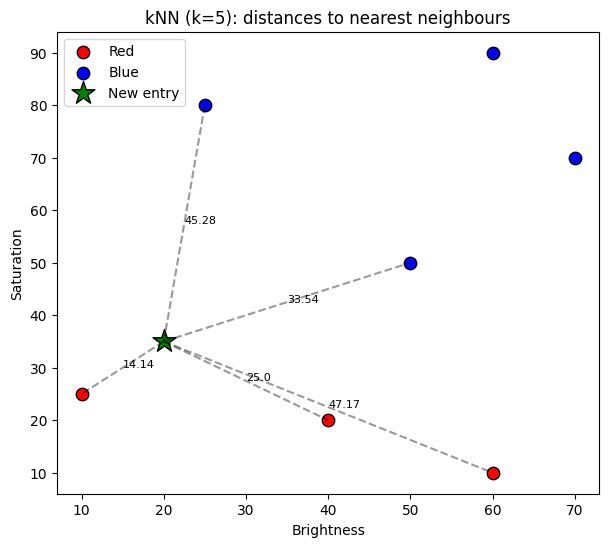

In [8]:
plt.figure(figsize=(7, 6))
for cls, colour in [('Red', 'red'), ('Blue', 'blue')]:
    pts = data[data['Class'] == cls]
    plt.scatter(pts['Brightness'], pts['Saturation'], c=colour, s=80, label=cls, edgecolors='k')
for _, row in nearest.iterrows():
    plt.plot([20, row['Brightness']], [35, row['Saturation']], 'k--', alpha=0.4)
    plt.annotate(row['Distance'], ((20 + row['Brightness']) / 2, (35 + row['Saturation']) / 2), fontsize=8)
plt.scatter(20, 35, c='green', marker='*', s=300, label='New entry', edgecolors='k')
plt.xlabel('Brightness'); plt.ylabel('Saturation'); plt.title(f'kNN (k={k}): distances to nearest neighbours')
plt.legend()
plt.show()